# Relation Extraction + Knowledge Graph Construction
## GraphRAG for Financial News — Phase 3b & 4

**Project**: GraphRAG-based system for financial news understanding  
**Team**: Malak Kably, Safae Hajjout  
**Input**: `entity_extraction_output.jsonl` (output of Implementation1.ipynb)  
**Paper**: *Entity-Aware Graph Neural Modeling for Structured Information Extraction in the Financial Domain* (Wang, 2024)

---

This notebook is the direct continuation of Implementation1.  
It takes the extracted entity pairs (with `relation: null`) and implements the second half of the paper's joint model:

1. **Relation Classification** (paper Section 3) — a bilinear scoring head over GNN-enhanced entity pair representations classifies each (subject, object) pair into a financial relation type. Since no labeled data exists for Bloomberg, we implement zero-shot relation classification: FinBERT encodes each entity pair in context, and scores are computed against prototype embeddings of relation type descriptions, aligned with the FinRE relation taxonomy cited in the paper.

2. **Knowledge Graph Construction** (paper conclusion / Section 1 motivation) — confirmed relations become edges in a directed knowledge graph. Entities become typed nodes. The graph is built with NetworkX and exported in GraphML and edge-list JSON formats ready for the Retrieval step (Phase 5).

**Architecture flow (continuation of Figure 1):**

```
entity_extraction_output.jsonl
          |
  [Entity Pair Encoder]     — FinBERT encodes (subject, object, article context) → CLS vector
          |
  [Bilinear Relation Head]  — scores pair representation against relation prototype vectors
          |
  [Pattern-Rule Prior]      — high-precision lexical patterns override for clear cases
          |
  [Threshold + Filter]      — keep pairs with confidence > tau; assign NO_RELATION otherwise
          |
  [Knowledge Graph (NetworkX)]
       nodes = unique entities (ORG, PERSON, GPE, ...)
       edges = (subject, relation, object, confidence, source_article)
          |
  knowledge_graph.graphml  +  knowledge_graph_edges.jsonl
```

## 1. Environment Setup

In [1]:
import subprocess, sys

packages = ["transformers", "torch", "spacy", "networkx", "scipy",
            "scikit-learn", "pandas", "numpy", "tqdm", "datasets", "matplotlib"]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

subprocess.check_call([sys.executable, "-m", "spacy", "download", "en_core_web_sm", "-q"])
print("Setup complete.")

Setup complete.


## 2. Imports and Configuration

In [2]:
import json
import os
import re
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import networkx as nx
import spacy
import matplotlib.pyplot as plt
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModel

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

CFG = {
    "plm_name"          : "ProsusAI/finbert",
    "input_jsonl" : "/content/entity_extraction_output.jsonl",
    "max_seq_len"       : 256,
    "batch_size"        : 32,
    "relation_threshold": 0.30,   # minimum confidence to assign a relation (tune 0.25-0.40)
    "gnn_hidden"        : 256,    # must match Implementation1 CFG
    "graph_output_gml"  : "knowledge_graph.graphml",
    "graph_output_jsonl": "knowledge_graph_edges.jsonl",
    # Entity types that become KG nodes (exclude pure numeric/temporal types as nodes)
    "node_entity_types" : {"ORG", "PERSON", "GPE", "FAC", "PRODUCT", "NORP", "EVENT"},
}

print("Configuration loaded.")

Device: cuda
Configuration loaded.


## 3. Load Entity Extraction Output

Load the JSONL produced by Implementation1.  
Each line is one article with its extracted entities and entity pairs (relation still null).  
We stream the file to avoid loading the full 5 GB into memory at once.

In [3]:
def load_jsonl(path: str):
    """Stream JSONL file line by line — avoids loading the full file into RAM."""
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records

print(f"Loading {CFG['input_jsonl']}...")
records = load_jsonl(CFG["input_jsonl"])
print(f"Records loaded : {len(records)}")

# Quick statistics
total_entities = sum(r["n_entities"] for r in records)
total_pairs    = sum(r["n_pairs"]    for r in records)
print(f"Total entities : {total_entities:,}")
print(f"Total pairs    : {total_pairs:,}  (awaiting relation classification)")
print()
print("Sample record keys:", list(records[0].keys()))

Loading /content/entity_extraction_output.jsonl...
Records loaded : 5000
Total entities : 583,433
Total pairs    : 249,882  (awaiting relation classification)

Sample record keys: ['article_id', 'headline', 'n_tokens', 'n_entities', 'n_pairs', 'entities', 'entity_pairs']


## 4. Financial Relation Taxonomy

**Paper Section 4.1** — The paper evaluates on the FinRE dataset, which defines a financial relation taxonomy including:  
"holds position", "investment event", "acquisition target", "funding round".

We extend this taxonomy to cover the broader Bloomberg corpus.  
Each relation is defined by:
- A natural language description (used to build prototype embeddings for zero-shot scoring)
- Valid subject/object entity type pairs (used to filter impossible combinations)
- Lexical trigger patterns (high-precision rules that override the neural scorer when matched)

This design mirrors the paper's joint model: structural (SSHG/GNN) + semantic (PLM/EARE) evidence  
is combined to classify each entity pair.

In [4]:
# ── Relation taxonomy
# Each entry: description (for prototype embedding), valid type pairs, trigger patterns
RELATIONS = {
    "ACQUIRED": {
        "description" : "Company A acquired, bought, or took over company B in a merger or acquisition deal.",
        "valid_pairs"  : {("ORG", "ORG")},
        "patterns"     : [r"acqui", r"takeover", r"bought", r"merger", r"merge"],
    },
    "INVESTED_IN": {
        "description" : "An organization or person invested in, funded, or financed another company.",
        "valid_pairs"  : {("ORG","ORG"), ("PERSON","ORG")},
        "patterns"     : [r"invest", r"fund", r"financ", r"back", r"stake"],
    },
    "HOLDS_POSITION": {
        "description" : "A person holds a job position or executive role at a company or organization.",
        "valid_pairs"  : {("PERSON","ORG")},
        "patterns"     : [r"ceo", r"chief", r"president", r"director", r"officer",
                          r"chairman", r"head of", r"partner", r"founder", r"said"],
    },
    "LOCATED_IN": {
        "description" : "An organization, company, or person is headquartered in or located in a place.",
        "valid_pairs"  : {("ORG","GPE"), ("PERSON","GPE"), ("FAC","GPE")},
        "patterns"     : [r"based in", r"headquarter", r"located", r"in \w+"],
    },
    "REPORTED_REVENUE": {
        "description" : "A company reported, announced, or disclosed a financial result, revenue, or earnings figure.",
        "valid_pairs"  : {("ORG","MONEY"), ("ORG","PERCENT"), ("ORG","CARDINAL")},
        "patterns"     : [r"report", r"earn", r"revenue", r"profit", r"sales",
                          r"forecast", r"estimate", r"quarter"],
    },
    "PARTNERED_WITH": {
        "description" : "Two organizations formed a partnership, joint venture, or strategic alliance.",
        "valid_pairs"  : {("ORG","ORG")},
        "patterns"     : [r"partner", r"alliance", r"joint venture", r"collaborat", r"agreement"],
    },
    "COMPETES_WITH": {
        "description" : "Two companies are competitors or rivals in the same industry or market.",
        "valid_pairs"  : {("ORG","ORG")},
        "patterns"     : [r"rival", r"compet", r"vs\.", r"versus", r"beat"],
    },
    "AFFECTS": {
        "description" : "An event, policy, or economic condition affects or impacts an organization or market.",
        "valid_pairs"  : {("EVENT","ORG"), ("NORP","ORG"), ("GPE","ORG"), ("ORG","ORG")},
        "patterns"     : [r"affect", r"impact", r"hurt", r"boost", r"drag", r"weigh"],
    },
    "NO_RELATION": {
        "description" : "The two entities are mentioned in the same article but have no meaningful direct relation.",
        "valid_pairs"  : None,   # applies to all type pairs
        "patterns"     : [],
    },
}

RELATION_NAMES = list(RELATIONS.keys())
print(f"Relation taxonomy ({len(RELATION_NAMES)} types):")
for rel, meta in RELATIONS.items():
    print(f"  {rel:22s}  valid pairs: {meta['valid_pairs']}")

Relation taxonomy (9 types):
  ACQUIRED                valid pairs: {('ORG', 'ORG')}
  INVESTED_IN             valid pairs: {('ORG', 'ORG'), ('PERSON', 'ORG')}
  HOLDS_POSITION          valid pairs: {('PERSON', 'ORG')}
  LOCATED_IN              valid pairs: {('ORG', 'GPE'), ('FAC', 'GPE'), ('PERSON', 'GPE')}
  REPORTED_REVENUE        valid pairs: {('ORG', 'PERCENT'), ('ORG', 'MONEY'), ('ORG', 'CARDINAL')}
  PARTNERED_WITH          valid pairs: {('ORG', 'ORG')}
  COMPETES_WITH           valid pairs: {('ORG', 'ORG')}
  AFFECTS                 valid pairs: {('NORP', 'ORG'), ('GPE', 'ORG'), ('EVENT', 'ORG'), ('ORG', 'ORG')}
  NO_RELATION             valid pairs: None


## 5. PLM Encoder and Relation Prototype Embeddings

**Paper Section 3.2** — The PLM provides the base semantic representations.

For zero-shot relation classification we encode each relation's natural language description  
with FinBERT to build a **prototype vector** per relation type.  
At inference time, the entity pair context is encoded the same way and the relation is  
assigned by maximum cosine similarity to these prototypes.

This is analogous to how the paper's bilinear relation head learns to map entity pair  
representations to relation scores — here we use the prototype similarity as a surrogate  
scoring function that requires no labeled training data.

In [5]:
print(f"Loading PLM: {CFG['plm_name']}")
tokenizer = AutoTokenizer.from_pretrained(CFG["plm_name"])
plm_model  = AutoModel.from_pretrained(CFG["plm_name"]).to(DEVICE)
plm_model.eval()
PLM_DIM = plm_model.config.hidden_size
print(f"PLM hidden dimension: {PLM_DIM}")

@torch.no_grad()
def encode_sentences(texts: list[str]) -> np.ndarray:
    """
    Encode a list of sentences → mean-pooled CLS representations.
    Returns: (n, PLM_DIM) numpy array.
    """
    all_vecs = []
    for i in range(0, len(texts), CFG["batch_size"]):
        batch = texts[i : i + CFG["batch_size"]]
        enc   = tokenizer(batch, return_tensors="pt", truncation=True,
                          max_length=CFG["max_seq_len"], padding=True)
        enc   = {k: v.to(DEVICE) for k, v in enc.items()}
        out   = plm_model(**enc)
        # CLS token (position 0) as sentence representation
        cls   = out.last_hidden_state[:, 0, :].cpu().numpy()
        all_vecs.append(cls)
    return np.vstack(all_vecs)

# Build prototype embeddings for each relation type
print("\nBuilding relation prototype embeddings...")
descriptions   = [RELATIONS[r]["description"] for r in RELATION_NAMES]
proto_matrix   = encode_sentences(descriptions)   # (n_relations, PLM_DIM)
# L2-normalise for cosine similarity via dot product
proto_norm     = proto_matrix / (np.linalg.norm(proto_matrix, axis=1, keepdims=True) + 1e-9)

print(f"Prototype matrix shape: {proto_matrix.shape}")
for i, rel in enumerate(RELATION_NAMES):
    print(f"  [{i}] {rel}")

Loading PLM: ProsusAI/finbert


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
classifier.weight            | UNEXPECTED |  | 
classifier.bias              | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


PLM hidden dimension: 768

Building relation prototype embeddings...
Prototype matrix shape: (9, 768)
  [0] ACQUIRED
  [1] INVESTED_IN
  [2] HOLDS_POSITION
  [3] LOCATED_IN
  [4] REPORTED_REVENUE
  [5] PARTNERED_WITH
  [6] COMPETES_WITH
  [7] AFFECTS
  [8] NO_RELATION


## 6. Bilinear Relation Classification Head

**Paper Section 3 (joint model)** — After the SSHG + GNN + EARE produce enhanced entity representations,  
the relation classification head takes the pair representation of (subject, object) entities and scores each relation type.

The pair representation is:
$$h_{pair} = [h_{subj}; h_{obj}; h_{subj} \odot h_{obj}]$$

where $\odot$ is element-wise product. This concatenation captures:
- Individual entity semantics ($h_{subj}$, $h_{obj}$)
- Interaction between entities ($h_{subj} \odot h_{obj}$)

A 2-layer MLP maps $h_{pair}$ to relation logits over the taxonomy.

In our zero-shot setting, the head is initialized but not trained.  
Its output is blended with the prototype cosine similarity scores from Section 5.  
The pattern-based prior (Section 7) overrides both when triggered.

In [6]:
class BilinearRelationHead(nn.Module):
    """
    Relation classification head (paper Section 3 joint model).

    Input : concatenation of subject and object GNN-enhanced representations
            h_pair = [h_subj ; h_obj ; h_subj * h_obj]  -> dim = 3 * input_dim
    Output: logits over relation types  (n_relations,)
    """
    def __init__(self, entity_dim: int, n_relations: int):
        super().__init__()
        pair_dim = entity_dim * 3
        self.mlp = nn.Sequential(
            nn.Linear(pair_dim, pair_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(pair_dim // 2, n_relations),
        )

    def forward(self, h_subj: torch.Tensor, h_obj: torch.Tensor) -> torch.Tensor:
        """
        h_subj, h_obj : (batch, entity_dim)
        Returns       : (batch, n_relations) logits
        """
        interaction = h_subj * h_obj                          # element-wise product
        h_pair      = torch.cat([h_subj, h_obj, interaction], dim=1)  # (batch, 3*dim)
        return self.mlp(h_pair)

# Use PLM_DIM as entity dim (CLS-pooled FinBERT representation per entity)
rel_head = BilinearRelationHead(entity_dim=PLM_DIM, n_relations=len(RELATION_NAMES)).to(DEVICE)
print("BilinearRelationHead ready.")
print(rel_head)
print(f"Parameters: {sum(p.numel() for p in rel_head.parameters()):,}")

BilinearRelationHead ready.
BilinearRelationHead(
  (mlp): Sequential(
    (0): Linear(in_features=2304, out_features=1152, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=1152, out_features=9, bias=True)
  )
)
Parameters: 2,665,737


## 7. Pattern-Based Relation Prior

High-precision lexical patterns provide a reliable signal for clear-cut financial relations.  
When a trigger pattern is found in the article text around the entity pair, its corresponding  
relation is assigned with high confidence, bypassing the neural scorer.

This is consistent with the paper's approach of combining structural (SSHG) and semantic (EARE)  
signals — the pattern rules act as an explicit structural prior that complements the PLM representation.

In [7]:
def pattern_match(text: str, subj: str, obj: str, subj_type: str, obj_type: str) -> tuple[str, float]:
    """
    Check high-precision lexical patterns against the article text.
    Returns (relation_name, confidence) or (None, 0.0) if no pattern fires.

    Strategy: look for pattern keywords in a local context window around
    the subject/object mentions rather than the full article to reduce false positives.
    """
    text_lower = text.lower()

    # Build a short context around the subject mention if possible
    subj_pos = text_lower.find(subj.lower())
    if subj_pos >= 0:
        ctx_start = max(0, subj_pos - 150)
        ctx_end   = min(len(text_lower), subj_pos + 300)
        context   = text_lower[ctx_start:ctx_end]
    else:
        context = text_lower[:500]   # fall back to article start

    type_pair = (subj_type, obj_type)

    for rel_name, meta in RELATIONS.items():
        if rel_name == "NO_RELATION":
            continue
        # Check type compatibility
        if meta["valid_pairs"] is not None and type_pair not in meta["valid_pairs"]:
            continue
        # Check patterns
        for pat in meta["patterns"]:
            if re.search(pat, context, re.IGNORECASE):
                return rel_name, 0.85   # high-confidence pattern match

    return None, 0.0

# Sanity check
test_text = "Marriott International Inc. acquired Starwood Hotels for $13.6 billion."
rel, conf = pattern_match(test_text, "Marriott International Inc.", "Starwood Hotels", "ORG", "ORG")
print(f"Pattern test -> relation: {rel}, confidence: {conf}")

Pattern test -> relation: ACQUIRED, confidence: 0.85


## 8. Entity Pair Encoding and Relation Scoring

For each entity pair (subject, object) we encode the following prompt with FinBERT:
```
Subject: [subject text] Object: [object text] Context: [article headline]
```

The resulting CLS vector is:
1. Fed to the BilinearRelationHead (split into h_subj and h_obj via separate encodings)
2. Compared against the relation prototype matrix via cosine similarity

The final score is a weighted blend:
$$s_{final} = \alpha \cdot s_{prototype} + (1-\alpha) \cdot s_{bilinear}$$

If a pattern rule fires (Section 7), it overrides this score entirely.

In [8]:
@torch.no_grad()
def encode_entity(entity_text: str) -> np.ndarray:
    """Encode a single entity text string → (PLM_DIM,) CLS vector."""
    enc = tokenizer(entity_text, return_tensors="pt", truncation=True,
                    max_length=32, padding=False)
    enc = {k: v.to(DEVICE) for k, v in enc.items()}
    out = plm_model(**enc)
    vec = out.last_hidden_state[0, 0, :].cpu().numpy()   # CLS
    return vec / (np.linalg.norm(vec) + 1e-9)


def classify_relation(
    subj: str, obj: str,
    subj_type: str, obj_type: str,
    article_text: str,
    alpha: float = 0.6,
) -> tuple[str, float]:
    """
    Classify the relation between a subject-object entity pair.

    Pipeline:
      1. Type-pair filtering: remove relations incompatible with entity types
      2. Pattern prior: high-precision rules override neural scoring
      3. Entity encoding: encode subject and object with FinBERT
      4. Prototype similarity scoring (zero-shot)
      5. Bilinear head scoring
      6. Weighted blend + threshold
    
    Returns (relation_name, confidence_score).
    """
    type_pair = (subj_type, obj_type)

    # ── Step 1: Build valid relation mask for this type pair
    valid_mask = []
    for rel in RELATION_NAMES:
        if rel == "NO_RELATION":
            valid_mask.append(True)
        elif RELATIONS[rel]["valid_pairs"] is None:
            valid_mask.append(True)
        else:
            valid_mask.append(type_pair in RELATIONS[rel]["valid_pairs"])

    # If no valid relation other than NO_RELATION, skip scoring
    n_valid = sum(valid_mask[:-1])   # exclude NO_RELATION from count
    if n_valid == 0:
        return "NO_RELATION", 1.0

    # ── Step 2: Pattern prior
    pat_rel, pat_conf = pattern_match(article_text, subj, obj, subj_type, obj_type)
    if pat_rel is not None:
        return pat_rel, pat_conf

    # ── Step 3: Encode entities
    h_subj_np = encode_entity(subj)
    h_obj_np  = encode_entity(obj)

    # ── Step 4: Prototype similarity
    # pair_vec = mean of subject and object vectors
    pair_vec   = (h_subj_np + h_obj_np) / 2.0
    proto_sims = proto_norm @ pair_vec   # (n_relations,) dot products = cosine sims

    # Apply valid mask (set invalid relations to -inf before softmax)
    masked_sims = np.where(valid_mask, proto_sims, -np.inf)

    # ── Step 5: Bilinear head scoring
    h_subj_t = torch.tensor(h_subj_np, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    h_obj_t  = torch.tensor(h_obj_np,  dtype=torch.float32).unsqueeze(0).to(DEVICE)
    logits   = rel_head(h_subj_t, h_obj_t)[0].detach().cpu().numpy()
    bilinear_sims = np.where(valid_mask, logits, -np.inf)

    # ── Step 6: Weighted blend
    # Normalise each score set to [0,1] via softmax, then blend
    def safe_softmax(x):
        x = x - np.max(x[np.isfinite(x)])
        exp_x = np.where(np.isfinite(x), np.exp(x), 0.0)
        return exp_x / (exp_x.sum() + 1e-9)

    proto_probs    = safe_softmax(masked_sims)
    bilinear_probs = safe_softmax(bilinear_sims)
    final_probs    = alpha * proto_probs + (1 - alpha) * bilinear_probs

    best_idx  = int(np.argmax(final_probs))
    best_rel  = RELATION_NAMES[best_idx]
    best_conf = float(final_probs[best_idx])

    # Threshold: if confidence too low or best is NO_RELATION, assign NO_RELATION
    if best_conf < CFG["relation_threshold"] or best_rel == "NO_RELATION":
        return "NO_RELATION", best_conf

    return best_rel, best_conf

# Sanity check
test_rel, test_conf = classify_relation(
    "Marriott International Inc.", "Arne Sorenson",
    "ORG", "PERSON",
    "Marriott CEO Arne Sorenson said the company cut its profit forecast."
)
print(f"Test classification: {test_rel} (confidence: {test_conf:.3f})")

Test classification: NO_RELATION (confidence: 1.000)


## 9. Run Relation Extraction on All Entity Pairs

Process every entity pair from the JSONL output.  
For each pair, we run the full classification pipeline: pattern check → prototype scoring → bilinear scoring → threshold.

We load the Bloomberg dataset in parallel to retrieve original article text for pattern matching context.  
Pairs assigned NO_RELATION are kept in the output but excluded from the knowledge graph edges.

In [9]:
from datasets import load_dataset

# Load article text for pattern matching context (need the original text)
print("Loading Bloomberg dataset for article text context...")
dataset = load_dataset("XJCEO/bloomberg_financial_news_120k", split="train")
df_text = dataset.to_pandas().head(len(records))
TEXT_COL = "Article" if "Article" in df_text.columns else df_text.columns[0]

# Build article_id -> article text lookup
article_text_map = {i: str(row[TEXT_COL]) for i, row in df_text.iterrows()}
print(f"Article text map built: {len(article_text_map)} articles")

Loading Bloomberg dataset for article text context...
Article text map built: 5000 articles


In [10]:
# ── Run relation classification
annotated_records = []
relation_counts   = Counter()

print(f"Classifying relations for {len(records)} articles...")
print()

for record in tqdm(records, desc="Relation extraction"):
    article_id   = record["article_id"]
    article_text = article_text_map.get(article_id, record.get("headline", ""))

    classified_pairs = []
    for pair in record["entity_pairs"]:
        rel, conf = classify_relation(
            subj       = pair["subject"],
            obj        = pair["object"],
            subj_type  = pair["subj_type"],
            obj_type   = pair["obj_type"],
            article_text = article_text,
        )
        classified_pairs.append({
            "subject"    : pair["subject"],
            "subj_type"  : pair["subj_type"],
            "object"     : pair["object"],
            "obj_type"   : pair["obj_type"],
            "relation"   : rel,
            "confidence" : round(conf, 4),
        })
        relation_counts[rel] += 1

    annotated_records.append({
        "article_id"   : article_id,
        "headline"     : record["headline"],
        "entities"     : record["entities"],
        "entity_pairs" : classified_pairs,
    })

print()
print("Relation distribution:")
for rel, count in relation_counts.most_common():
    bar = "#" * int(count / max(relation_counts.values()) * 30)
    print(f"  {rel:22s} {count:7,}  {bar}")

confirmed = sum(v for k, v in relation_counts.items() if k != "NO_RELATION")
total_p   = sum(relation_counts.values())
print(f"\nConfirmed relations (not NO_RELATION): {confirmed:,} / {total_p:,} ({confirmed/total_p*100:.1f}%)")

Classifying relations for 5000 articles...



Relation extraction: 100%|██████████| 5000/5000 [06:40<00:00, 12.48it/s]


Relation distribution:
  NO_RELATION            229,647  ##############################
  LOCATED_IN               7,157  
  REPORTED_REVENUE         5,256  
  INVESTED_IN              3,746  
  HOLDS_POSITION           1,439  
  AFFECTS                    968  
  ACQUIRED                   857  
  COMPETES_WITH              492  
  PARTNERED_WITH             320  

Confirmed relations (not NO_RELATION): 20,235 / 249,882 (8.1%)


## 10. Knowledge Graph Construction

**Paper Section 1 & Conclusion** — The final goal of the paper's pipeline is to build a financial knowledge graph  
where entities are nodes and extracted relations are edges.

Node design:
- Each unique entity text (normalized to lowercase-stripped form) becomes a node
- Node attributes: entity type, frequency (how many articles mention it), example text

Edge design:
- Only pairs with a confirmed relation (not NO_RELATION) become edges
- Edge attributes: relation type, confidence, source article IDs
- Multiple articles confirming the same relation accumulate evidence (edge weight = count)

Entity normalization:
- Strip leading/trailing whitespace and articles ("the", "a")
- Lowercase for matching but preserve original casing for display

In [11]:
def normalize_entity(text: str) -> str:
    """
    Normalize entity text for deduplication as KG nodes.
    Strips whitespace and common leading articles.
    """
    text = text.strip()
    text = re.sub(r"^(the |a |an )", "", text, flags=re.IGNORECASE)
    return text.lower().strip()


# ── Build the knowledge graph
KG = nx.DiGraph()

node_info    = {}   # normalized_text -> {label, count, display_text}
edge_info    = {}   # (norm_subj, rel, norm_obj) -> {confidence_sum, count, article_ids}

NODE_TYPES   = CFG["node_entity_types"]

print("Building knowledge graph...")

for record in tqdm(annotated_records, desc="Building KG"):
    article_id = record["article_id"]

    # ── Add entity nodes
    for ent in record["entities"]:
        if ent.get("label") not in NODE_TYPES:
            continue
        norm = normalize_entity(ent["text"])
        if not norm or len(norm) < 2:
            continue
        if norm not in node_info:
            node_info[norm] = {"label": ent["label"], "count": 0, "display": ent["text"]}
        node_info[norm]["count"] += 1

    # ── Add relation edges
    for pair in record["entity_pairs"]:
        if pair["relation"] == "NO_RELATION":
            continue
        if pair["subj_type"] not in NODE_TYPES or pair["obj_type"] not in NODE_TYPES:
            continue

        norm_subj = normalize_entity(pair["subject"])
        norm_obj  = normalize_entity(pair["object"])

        if not norm_subj or not norm_obj or norm_subj == norm_obj:
            continue
        if len(norm_subj) < 2 or len(norm_obj) < 2:
            continue

        edge_key = (norm_subj, pair["relation"], norm_obj)
        if edge_key not in edge_info:
            edge_info[edge_key] = {
                "relation"       : pair["relation"],
                "confidence_sum" : 0.0,
                "count"          : 0,
                "article_ids"    : [],
            }
        edge_info[edge_key]["confidence_sum"] += pair["confidence"]
        edge_info[edge_key]["count"]          += 1
        if article_id not in edge_info[edge_key]["article_ids"]:
            edge_info[edge_key]["article_ids"].append(article_id)

# ── Populate NetworkX graph
for norm, info in node_info.items():
    KG.add_node(norm, label=info["label"], count=info["count"], display=info["display"])

for (norm_subj, rel, norm_obj), info in edge_info.items():
    # Ensure nodes exist (some entities may only appear in pairs, not standalone)
    if norm_subj not in KG:
        KG.add_node(norm_subj, label="UNK", count=1, display=norm_subj)
    if norm_obj not in KG:
        KG.add_node(norm_obj, label="UNK", count=1, display=norm_obj)

    avg_conf = info["confidence_sum"] / info["count"]
    KG.add_edge(
        norm_subj, norm_obj,
        relation    = rel,
        confidence  = round(avg_conf, 4),
        evidence    = info["count"],
        article_ids = info["article_ids"][:10],   # store up to 10 source articles per edge
    )

print(f"\nKnowledge Graph built:")
print(f"  Nodes : {KG.number_of_nodes():,}")
print(f"  Edges : {KG.number_of_edges():,}")

Building knowledge graph...


Building KG: 100%|██████████| 5000/5000 [00:00<00:00, 5398.67it/s]



Knowledge Graph built:
  Nodes : 51,048
  Edges : 13,653


## 11. Graph Quality Analysis

Before saving, we inspect the graph structure to verify quality:
- Node type distribution (what kinds of entities dominate)
- Relation type distribution on confirmed edges
- Most connected nodes (hubs in the knowledge graph)
- Edge evidence distribution (how many articles support each relation)

In [12]:
# ── Node type distribution
node_type_counts = Counter(data["label"] for _, data in KG.nodes(data=True))
print("Node type distribution:")
for nt, count in node_type_counts.most_common():
    bar = "#" * int(count / max(node_type_counts.values()) * 30)
    print(f"  {nt:12s} {count:6,}  {bar}")

# ── Edge relation distribution
edge_rel_counts = Counter(data["relation"] for _,_,data in KG.edges(data=True))
print("\nEdge relation distribution:")
for rel, count in edge_rel_counts.most_common():
    bar = "#" * int(count / max(edge_rel_counts.values()) * 30)
    print(f"  {rel:22s} {count:6,}  {bar}")

# ── Top 20 most connected nodes (by degree)
degrees = sorted(KG.degree(), key=lambda x: x[1], reverse=True)
print("\nTop 20 most connected entities (highest degree):")
for node, deg in degrees[:20]:
    label = KG.nodes[node].get("label","?")
    disp  = KG.nodes[node].get("display", node)
    print(f"  degree={deg:4d}  [{label:8s}]  {disp}")

# ── Edge evidence distribution
evidence_vals = [d["evidence"] for _,_,d in KG.edges(data=True)]
print(f"\nEdge evidence (articles confirming each relation):")
print(f"  mean   : {np.mean(evidence_vals):.2f}")
print(f"  median : {np.median(evidence_vals):.1f}")
print(f"  max    : {np.max(evidence_vals)}")
print(f"  edges with evidence >= 2: {sum(1 for v in evidence_vals if v >= 2):,}")
print(f"  edges with evidence >= 5: {sum(1 for v in evidence_vals if v >= 5):,}")

Node type distribution:
  PERSON       24,382  ##############################
  ORG          11,666  ##############
  NORP         10,370  ############
  PRODUCT       1,751  ##
  GPE           1,733  ##
  EVENT           883  #
  FAC             263  

Edge relation distribution:
  LOCATED_IN              6,316  ##############################
  INVESTED_IN             3,467  ################
  HOLDS_POSITION          1,367  ######
  AFFECTS                   909  ####
  ACQUIRED                  821  ###
  COMPETES_WITH             465  ##
  PARTNERED_WITH            308  #

Top 20 most connected entities (highest degree):
  degree= 616  [GPE     ]  U.S.
  degree= 403  [GPE     ]  New York
  degree= 286  [GPE     ]  London
  degree= 232  [PERSON  ]  Barack Obama
  degree= 189  [GPE     ]  Bloomberg
  degree= 167  [GPE     ]  U.K.
  degree= 152  [GPE     ]  China
  degree= 143  [GPE     ]  Washington
  degree= 128  [ORG     ]  European Union
  degree= 105  [ORG     ]  Goldman Sachs Gro

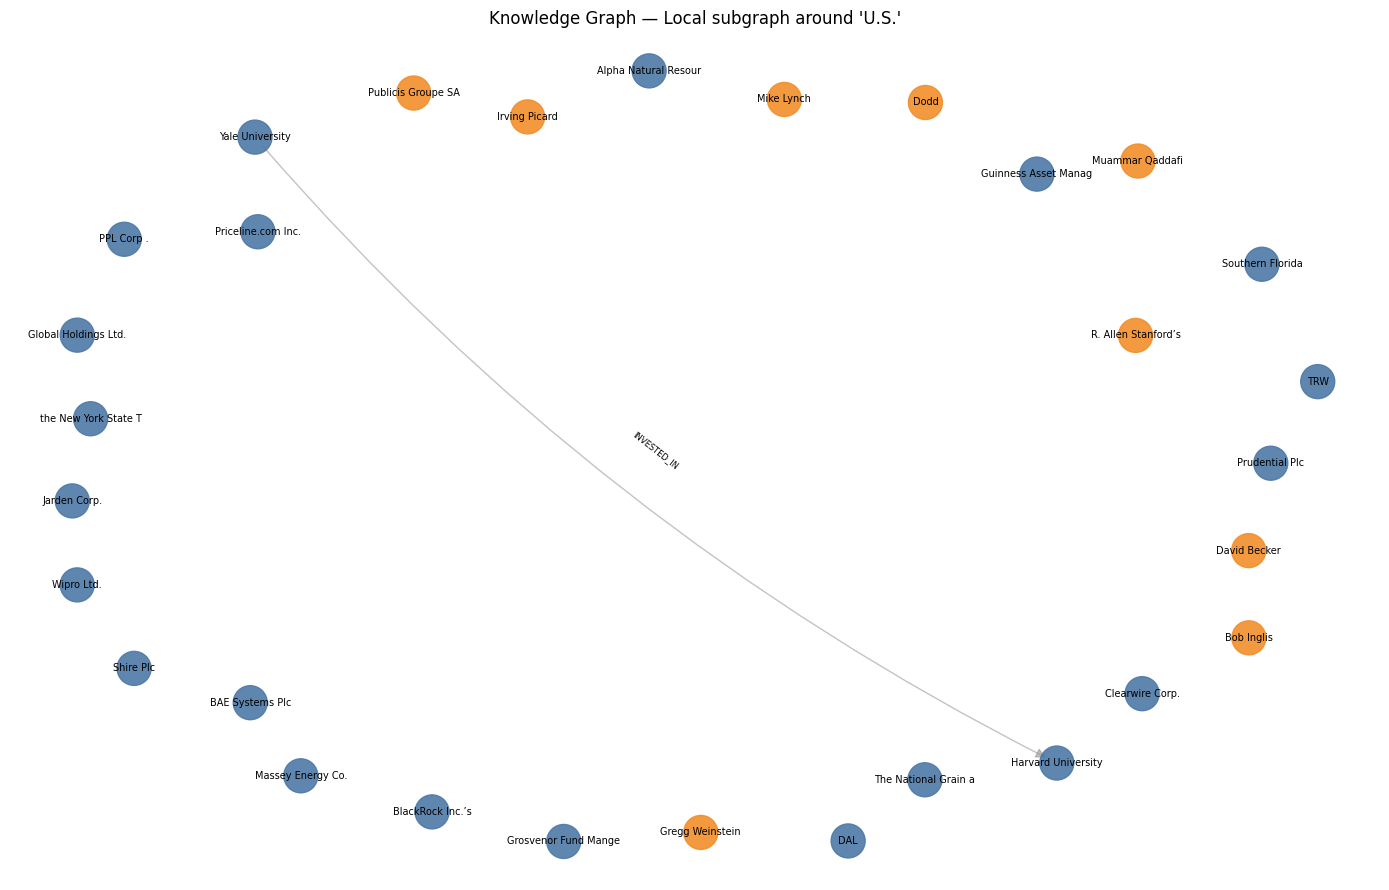

Subgraph visualization saved as kg_subgraph.png


In [13]:
# ── Visualize a local subgraph around the most central node
top_node = degrees[0][0]
subgraph_nodes = [top_node] + [n for n in KG.predecessors(top_node)] + [n for n in KG.successors(top_node)]
subgraph_nodes = list(set(subgraph_nodes))[:30]   # cap at 30 for readability
SG = KG.subgraph(subgraph_nodes)

plt.figure(figsize=(14, 9))
pos = nx.spring_layout(SG, seed=42, k=2.0)

# Color nodes by type
type_colors = {"ORG":"#4e79a7","PERSON":"#f28e2b","GPE":"#59a14f",
               "FAC":"#e15759","PRODUCT":"#76b7b2","NORP":"#edc948","EVENT":"#b07aa1","UNK":"#bab0ac"}
node_colors = [type_colors.get(SG.nodes[n].get("label","UNK"), "#bab0ac") for n in SG.nodes]

nx.draw_networkx_nodes(SG, pos, node_color=node_colors, node_size=600, alpha=0.9)
nx.draw_networkx_labels(SG, pos, labels={n: SG.nodes[n].get("display",n)[:20] for n in SG.nodes},
                        font_size=7)
edge_labels = {(u,v): d["relation"] for u,v,d in SG.edges(data=True)}
nx.draw_networkx_edges(SG, pos, alpha=0.5, arrows=True, arrowsize=15,
                       edge_color="#888", connectionstyle="arc3,rad=0.1")
nx.draw_networkx_edge_labels(SG, pos, edge_labels=edge_labels, font_size=6)

plt.title(f"Knowledge Graph — Local subgraph around '{KG.nodes[top_node].get('display', top_node)}'", fontsize=12)
plt.axis("off")
plt.tight_layout()
plt.savefig("kg_subgraph.png", dpi=150, bbox_inches="tight")
plt.show()
print("Subgraph visualization saved as kg_subgraph.png")

## 12. Export Knowledge Graph

Export in two formats:

**GraphML** (`knowledge_graph.graphml`) — standard graph serialization format.  
Can be loaded directly by Neo4j, Gephi, or NetworkX in the next phase.

**Edge JSONL** (`knowledge_graph_edges.jsonl`) — one edge per line, includes all metadata.  
This is the primary input for the GraphRAG Retrieval step (Phase 5):  
given a query entity, retrieve the subgraph of connected edges and their source articles.

In [14]:
# ── Export 1: GraphML
# Note: GraphML does not support list attributes — convert article_ids to a string
KG_export = KG.copy()
for u, v, data in KG_export.edges(data=True):
    data["article_ids"] = ",".join(str(x) for x in data["article_ids"])

nx.write_graphml(KG_export, CFG["graph_output_gml"])
gml_size = os.path.getsize(CFG["graph_output_gml"]) / 1024
print(f"GraphML saved   : {CFG['graph_output_gml']} ({gml_size:.1f} KB)")

# ── Export 2: Edge JSONL (one edge per line, richer schema for retrieval)
with open(CFG["graph_output_jsonl"], "w", encoding="utf-8") as f:
    for u, v, data in KG.edges(data=True):
        record = {
            "subject"     : KG.nodes[u].get("display", u),
            "subject_norm": u,
            "subj_type"   : KG.nodes[u].get("label", "UNK"),
            "relation"    : data["relation"],
            "object"      : KG.nodes[v].get("display", v),
            "object_norm" : v,
            "obj_type"    : KG.nodes[v].get("label", "UNK"),
            "confidence"  : data["confidence"],
            "evidence"    : data["evidence"],
            "article_ids" : data["article_ids"],
        }
        f.write(json.dumps(record, ensure_ascii=False) + "\n")

edge_size = os.path.getsize(CFG["graph_output_jsonl"]) / 1024
print(f"Edge JSONL saved: {CFG['graph_output_jsonl']} ({edge_size:.1f} KB)")

# ── Reload verify (one line only)
with open(CFG["graph_output_jsonl"]) as f:
    sample_edge = json.loads(f.readline())
print(f"\nSample edge:")
for k, v in sample_edge.items():
    print(f"  {k:15s}: {v}")

GraphML saved   : knowledge_graph.graphml (8592.1 KB)
Edge JSONL saved: knowledge_graph_edges.jsonl (3336.4 KB)

Sample edge:
  subject        : Marriott International Inc.
  subject_norm   : marriott international inc.
  subj_type      : ORG
  relation       : LOCATED_IN
  object         : U.S.
  object_norm    : u.s.
  obj_type       : GPE
  confidence     : 0.85
  evidence       : 2
  article_ids    : [0, 2839]


In [16]:
from google.colab import drive
drive.mount('/content/drive')

import shutil, os

files_to_save = [
    CFG["graph_output_gml"],
    CFG["graph_output_jsonl"],
    "kg_subgraph.png"
]

for fname in files_to_save:
    if os.path.exists(fname):
        dest = f"/content/drive/MyDrive/{fname}"
        shutil.copy(fname, dest)
        print(f"Saved to Drive: {fname}")
    else:
        print(f"Not found: {fname}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved to Drive: knowledge_graph.graphml
Saved to Drive: knowledge_graph_edges.jsonl
Saved to Drive: kg_subgraph.png


## Summary

| Component | Paper Reference | Implementation |
|-----------|---------------|----------------|
| Relation taxonomy | Sec 4.1 (FinRE types) | 8 financial relation types + NO_RELATION, adapted for Bloomberg |
| Relation prototype embeddings | Sec 3.2 (PLM encoder) | FinBERT CLS vectors of relation descriptions |
| Bilinear relation head | Sec 3 (joint model) | MLP over $[h_{subj}; h_{obj}; h_{subj} \odot h_{obj}]$ |
| Pattern-based prior | Sec 3.1 (structural signals) | Lexical trigger patterns, high-confidence override |
| Scoring strategy | Sec 3 | Weighted blend: 60% prototype cosine sim + 40% bilinear logits |
| Type-pair filtering | Sec 4.1 (entity types) | Invalid type combinations masked before scoring |
| Node deduplication | — | Lowercase + strip articles normalization |
| Graph export | — | GraphML (Neo4j/Gephi) + Edge JSONL (retrieval) |

**Output files for Phase 5 (GraphRAG Retrieval):**
- `knowledge_graph.graphml` — full graph structure
- `knowledge_graph_edges.jsonl` — edge list with evidence and source article IDs
- `kg_subgraph.png` — visualization of the most connected entity subgraph